In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
data= pd.read_csv("C:/Users/jayit/OneDrive/Documents/Project/Argo_and_All_Data.csv")
data

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.49900,15.298000,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.30200,9.739000,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
2,85.69400,9.306000,2011,1,1,25.614,-4.706,-1.344,4.894,665.526,-42.262,-108.105,-3.015,512.143,NaN,NaN,144.044,NaN,27
3,89.98200,11.161000,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.49500,10.955000,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14241,84.05400,10.169000,2020,12,29,26.866,-5.382,-2.492,5.931,626.547,-45.111,-87.921,-6.094,487.421,27.667,33.494,136.279,1539.066,36
14242,87.64900,15.012000,2020,12,29,25.997,-4.347,-4.278,6.099,62.918,-30.417,-152.537,-12.585,-132.620,27.402,33.017,129.507,1537.967,79
14243,88.62767,8.314662,2020,12,30,27.187,-5.810,-1.460,5.991,182.819,-46.693,-124.113,-13.168,-1.155,28.678,34.011,155.738,1541.841,74
14244,88.79500,10.344000,2020,12,31,27.360,-5.078,-4.438,6.744,203.434,-51.379,-176.908,-7.862,-32.717,28.343,33.876,149.373,1540.967,51


In [3]:
#df.fillna('NA')

In [4]:
df=data.dropna() 

In [5]:
df

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.49900,15.298000,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.30200,9.739000,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
3,89.98200,11.161000,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.49500,10.955000,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40
6,87.87100,14.038000,2011,1,4,26.440,-8.131,-5.485,9.809,357.742,-42.892,-276.453,-13.133,25.263,27.490,32.844,133.101,1537.984,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14241,84.05400,10.169000,2020,12,29,26.866,-5.382,-2.492,5.931,626.547,-45.111,-87.921,-6.094,487.421,27.667,33.494,136.279,1539.066,36
14242,87.64900,15.012000,2020,12,29,25.997,-4.347,-4.278,6.099,62.918,-30.417,-152.537,-12.585,-132.620,27.402,33.017,129.507,1537.967,79
14243,88.62767,8.314662,2020,12,30,27.187,-5.810,-1.460,5.991,182.819,-46.693,-124.113,-13.168,-1.155,28.678,34.011,155.738,1541.841,74
14244,88.79500,10.344000,2020,12,31,27.360,-5.078,-4.438,6.744,203.434,-51.379,-176.908,-7.862,-32.717,28.343,33.876,149.373,1540.967,51


In [6]:
df = df.drop(df[df['SLD'] <= 9].index)
df

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.49900,15.298000,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.30200,9.739000,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
3,89.98200,11.161000,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.49500,10.955000,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40
6,87.87100,14.038000,2011,1,4,26.440,-8.131,-5.485,9.809,357.742,-42.892,-276.453,-13.133,25.263,27.490,32.844,133.101,1537.984,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14241,84.05400,10.169000,2020,12,29,26.866,-5.382,-2.492,5.931,626.547,-45.111,-87.921,-6.094,487.421,27.667,33.494,136.279,1539.066,36
14242,87.64900,15.012000,2020,12,29,25.997,-4.347,-4.278,6.099,62.918,-30.417,-152.537,-12.585,-132.620,27.402,33.017,129.507,1537.967,79
14243,88.62767,8.314662,2020,12,30,27.187,-5.810,-1.460,5.991,182.819,-46.693,-124.113,-13.168,-1.155,28.678,34.011,155.738,1541.841,74
14244,88.79500,10.344000,2020,12,31,27.360,-5.078,-4.438,6.744,203.434,-51.379,-176.908,-7.862,-32.717,28.343,33.876,149.373,1540.967,51


In [7]:
# Step 2: Data Preprocessing
# Feature selection
x = df[['LON','LAT','Month','AirT','UWIND','VWIND','WIND','SWRAD','LWRAD','LATHF','SENHF','NETHF','SST','SSS','D23','SSVEL']]
y = df['SLD']

In [8]:
# Handle missing values (if any)
df.isnull().sum()

LON      0
LAT      0
Year     0
Month    0
Day      0
AirT     0
UWIND    0
VWIND    0
WIND     0
SWRAD    0
LWRAD    0
LATHF    0
SENHF    0
NETHF    0
SST      0
SSS      0
D23      0
SSVEL    0
SLD      0
dtype: int64

In [9]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [10]:
# Step 3: Model Training (Random Forest Classifier)
# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [12]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

y_pred = model.predict(x_test)

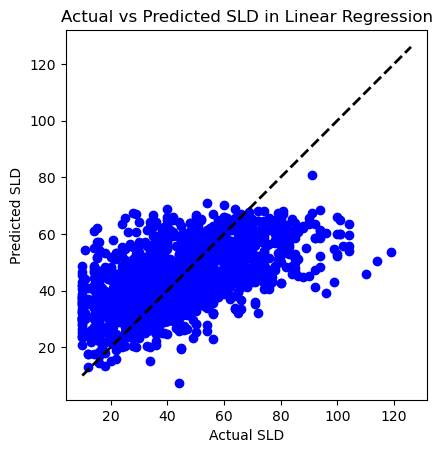

In [13]:
#define matplotlib figure and axis
fig, ax = plt.subplots()

#create simple line plot
ax.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
#plt.plot([y.min(), 100], [y.min(), 110], 'k--', lw=2)

plt.xlabel('Actual SLD')
plt.ylabel('Predicted SLD')
plt.title('Actual vs Predicted SLD in Linear Regression')


#attempt to set aspect ratio to 1
ax.set_aspect(1)

#display plot
plt.show()


In [14]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Squared Error:", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 243.70308847879062
Mean Absolute Squared Error: 12.226590619550318
R^2 Score: 0.33544331846031217


In [15]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

15.610992552646696